# Testing RECOVAR on CRLBD Dataset

In [4]:
import numpy as np
import torch
from seisbench.data import WaveformDataset
from recovar_torch.config import BATCH_SIZE, SAMPLING_FREQ
from recovar_torch.representation_learning_models import (
    RepresentationLearningMultipleAutoencoder,
    N_TIMESTEPS,
)
from recovar_torch.classifier_models import ClassifierMultipleAutoencoder
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt

### Configuration

In [6]:
EVENT_DATA_PATH = "/mnt/second_drive/ege/seisbench_data/datasets/crlbd/crlbd"
NOISE_DATA_PATH = "/mnt/second_drive/ege/seisbench_data/datasets/crlbd/crlbdnoise"

MODEL_PATH = "models/recovar_instance.pt"

COMPONENT_ORDER = "ZNE"
MAX_TRACES=3000 # test on a small subset: 3k event + 3k noise windows

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Load the CRLBD dataset

In [7]:
event_data = WaveformDataset(EVENT_DATA_PATH, sampling_rate=None, component_order=COMPONENT_ORDER)
noise_data = WaveformDataset(NOISE_DATA_PATH, sampling_rate=None, component_order=COMPONENT_ORDER)
print(f"Event traces: {len(event_data)}")
print(f"Noise traces: {len(noise_data)}")

Event traces: 224573
Noise traces: 67371


### Inspect trace shape and metadata

In [8]:
print(event_data.metadata[["trace_sampling_rate_hz"]].describe())
print([c for c in event_data.metadata.columns if "arrival" in c.lower()])
print("native shape :", event_data.get_waveforms(0).shape)
print("100 Hz shape :", event_data.get_waveforms(0, sampling_rate=SAMPLING_FREQ).shape)

       trace_sampling_rate_hz
count                224573.0
mean                    100.0
std                       0.0
min                     100.0
25%                     100.0
50%                     100.0
75%                     100.0
max                     100.0
['trace_P_arrival_time', 'trace_S_arrival_time', 'trace_P_arrival_sample', 'trace_S_arrival_sample']
native shape : (3, 12000)
100 Hz shape : (3, 12000)


### Build windows and labels

In [9]:
# RECOVAR needs 3000 sample windows: crop each trace to a 30s window aligned to the P/S pick,
# bandpass 1-20 Hz, then demean and L2 normalize, just like how we windowed INSTANCE/STEAD

FREQMIN = 1.0
FREQMAX = 20.0
PHASE_MARGIN = 500  # samples kept before the pick when cropping

_sos = butter(4, [FREQMIN, FREQMAX], btype="bandpass", fs=SAMPLING_FREQ, output="sos")


def _pick_sample(row):
    for col in ("trace_P_arrival_sample", "trace_p_arrival_sample", "trace_S_arrival_sample", "trace_s_arrival_sample"):
        if col in row and not np.isnan(row[col]):
            return float(row[col])
    return np.nan


def to_windows(dataset, use_pick):
    windows = []
    metadata = dataset.metadata
    for i in range(len(dataset)):
        if MAX_TRACES is not None and len(windows)>= MAX_TRACES:
            break
        wf = dataset.get_waveforms(i, sampling_rate=SAMPLING_FREQ)
        if wf.shape[0] < 3 or wf.shape[1] < N_TIMESTEPS:
            continue
        high = wf.shape[1] - N_TIMESTEPS
        start = 0
        if use_pick:
            pick = _pick_sample(metadata.iloc[i])
            if not np.isnan(pick):
                start = int(round(pick - PHASE_MARGIN))
        start = int(min(max(start, 0), high))
        windows.append(wf[:3, start : start + N_TIMESTEPS])
    return np.asarray(windows, dtype=np.float32)


def normalize(x):
    x = sosfiltfilt(_sos, x, axis=2)
    x = x - x.mean(axis=2, keepdims=True)
    norm = np.sqrt(np.sum(x ** 2, axis=2, keepdims=True))
    return (x / (1e-37 + norm)).astype(np.float32)

In [10]:
X_event = normalize(to_windows(event_data, use_pick=True))
X_noise = normalize(to_windows(noise_data, use_pick=False))

In [11]:
X_test = np.concatenate([X_event, X_noise], axis=0)
Y_test = np.concatenate([np.ones(len(X_event)), np.zeros(len(X_noise))]).astype(np.int64)

In [12]:
print(f"Test data shape: {X_test.shape}")
print(f"Test label shape: {Y_test.shape}")

Test data shape: (6000, 3, 3000)
Test label shape: (6000,)


### Load RECOVAR model

In [13]:
model = RepresentationLearningMultipleAutoencoder(input_noise_std=1e-6, eps=1e-27).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

RepresentationLearningMultipleAutoencoder(
  (normalize1): NormalizeStd()
  (add_noise): AddNoise()
  (normalize2): NormalizeStd()
  (autoencoders): ModuleList(
    (0-4): 5 x AutoencoderBlock(
      (down1): Downsample(
        (padding): Padding()
        (conv): Conv1d(3, 8, kernel_size=(15,), stride=(2,))
        (bn): BatchNorm1d(8, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
      (down2): Downsample(
        (padding): Padding()
        (conv): Conv1d(8, 16, kernel_size=(13,), stride=(2,))
        (bn): BatchNorm1d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
      (pad1): Padding()
      (down3): Downsample(
        (padding): Padding()
        (conv): Conv1d(16, 32, kernel_size=(11,), stride=(2,))
        (bn): BatchNorm1d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
      (down4): Downsample(
        (padding): Padding()
        (conv): Conv1d(32, 64, kernel_size=(9,), stride=(2,))
  

In [14]:
model_classifier = ClassifierMultipleAutoencoder(model).to(DEVICE)
model_classifier.eval()

ClassifierMultipleAutoencoder(
  (model): RepresentationLearningMultipleAutoencoder(
    (normalize1): NormalizeStd()
    (add_noise): AddNoise()
    (normalize2): NormalizeStd()
    (autoencoders): ModuleList(
      (0-4): 5 x AutoencoderBlock(
        (down1): Downsample(
          (padding): Padding()
          (conv): Conv1d(3, 8, kernel_size=(15,), stride=(2,))
          (bn): BatchNorm1d(8, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
        (down2): Downsample(
          (padding): Padding()
          (conv): Conv1d(8, 16, kernel_size=(13,), stride=(2,))
          (bn): BatchNorm1d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
        (pad1): Padding()
        (down3): Downsample(
          (padding): Padding()
          (conv): Conv1d(16, 32, kernel_size=(11,), stride=(2,))
          (bn): BatchNorm1d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
        (down4): Downsample(
       

### Score

In [16]:
scores = []
with torch.no_grad():
    for i in range(0, len(X_test), BATCH_SIZE):
        xb = torch.from_numpy(X_test[i : i + BATCH_SIZE]).to(DEVICE)
        xb=xb.transpose(1,2)
        scores.append(model_classifier(xb).cpu().numpy())
earthquake_scores = np.concatenate(scores)

### ROC Curve and AUC Score

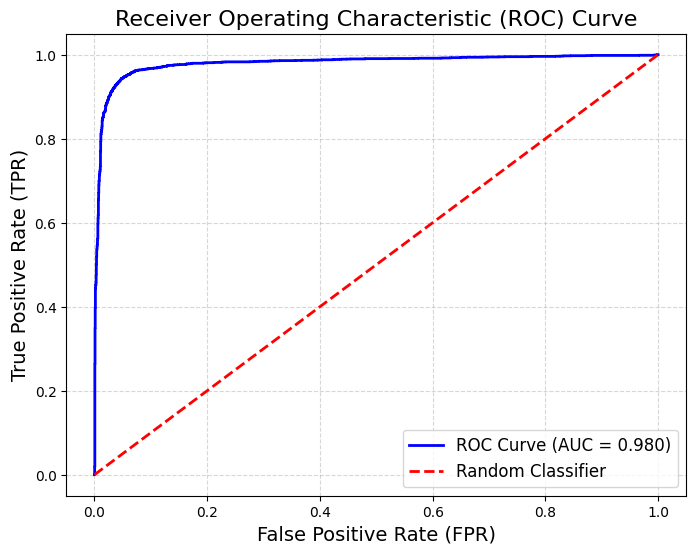

In [17]:
fpr, tpr, __ = roc_curve(Y_test, earthquake_scores)
auc_score = roc_auc_score(y_true=Y_test, y_score=earthquake_scores)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC Curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate (FPR)", fontsize=14)
plt.ylabel("True Positive Rate (TPR)", fontsize=14)
plt.title("Receiver Operating Characteristic (ROC) Curve", fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()